
### BQIS - Step 8: Clustering untuk Failure Pattern Discovery
### Lanjutan dari notebook EDA-Preprocessing-Modeling-SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

### 8.0 Reload & reprocess (biar file ini bisa jalan mandiri,
###     tanpa perlu run notebook sebelumnya dulu)

In [2]:
df = pd.read_csv("D:\\BQIS\\data\\bqis_biscuit_quality_dataset.csv")

failure_category_ref = df['Failure_Category'].copy()

df_model = df.drop(columns=['Sample_ID', 'Batch_Code', 'Test_Date', 'Failure_Category'])
df_model = pd.get_dummies(df_model, columns=['Product_Name'], prefix='Product')
df_model['Historical_Status'] = df_model['Historical_Status'].map({'Pass': 0, 'Fail': 1})

numeric_missing_cols = ['Moisture_Content_%', 'Fat_Content_%', 'Protein_Content_%',
                         'Water_Activity_Aw', 'Acid_Insoluble_Ash_%', 'Acid_Value_mgKOHg',
                         'Peroxide_Value', 'Lead_Pb_mgkg', 'Cadmium_Cd_mgkg']

imputer = KNNImputer(n_neighbors=5, weights='distance')
df_model[numeric_missing_cols] = imputer.fit_transform(df_model[numeric_missing_cols])

### 8.1 Subset hanya sampel FAIL
#### Logic: clustering di sini tujuannya "kenapa batch gagal punya pola apa aja",
#### bukan misahin Pass vs Fail (itu tugas classifier di step sebelumnya).
#### Kalau sampel Pass ikut dimasukkan, cluster yang terbentuk bakal didominasi
#### perbedaan Pass-vs-Fail, bukan sub-pola di dalam kegagalan itu sendiri.

In [4]:
fail_mask = df_model['Historical_Status'] == 1

numeric_feature_cols = numeric_missing_cols + ['Total_Plate_Count_CFUg', 'Yeast_Mold_Count_CFUg']
X_fail = df_model.loc[fail_mask, numeric_feature_cols].reset_index(drop=True)
cat_ref_fail = failure_category_ref[fail_mask].reset_index(drop=True)

print("Jumlah sampel Fail yang di-cluster:", len(X_fail))
print(cat_ref_fail.value_counts())


Jumlah sampel Fail yang di-cluster: 348
Failure_Category
Physicochemical    224
Heavy_Metal         69
Stability           29
Microbiological     26
Name: count, dtype: int64


### 8.2 Feature Scaling
#### WAJIB untuk K-Means & DBSCAN (beda sama XGBoost yang tree-based dan tidak
#### butuh scaling). Alasannya: kedua algoritma ini berbasis JARAK antar titik.
#### Kalau skala parameter beda jauh (misal Total_Plate_Count ribuan vs
#### Water_Activity 0-1), parameter dengan angka besar bakal mendominasi
#### perhitungan jarak walau secara substansi belum tentu lebih penting.

In [5]:
scaler = StandardScaler()
X_fail_scaled = scaler.fit_transform(X_fail)


### 8.3 K-Means -- cari jumlah cluster (k) optimal pakai Silhouette Score
#### Silhouette Score mengukur seberapa rapat sampel dalam satu cluster
#### dibanding jaraknya ke cluster lain. Range -1 sampai 1, makin tinggi makin
#### bagus pemisahan clusternya.

k=2 -> silhouette score = 0.135
k=3 -> silhouette score = 0.120
k=4 -> silhouette score = 0.121
k=5 -> silhouette score = 0.135
k=6 -> silhouette score = 0.146


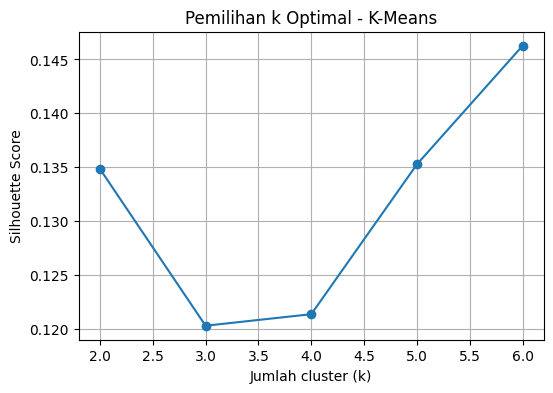


k optimal berdasarkan silhouette score: 6


In [6]:
silhouette_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_fail_scaled)
    score = silhouette_score(X_fail_scaled, labels)
    silhouette_scores[k] = score
    print(f"k={k} -> silhouette score = {score:.3f}")

plt.figure(figsize=(6,4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel("Jumlah cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Pemilihan k Optimal - K-Means")
plt.grid(True)
plt.show()

best_k = max(silhouette_scores, key=silhouette_scores.get)
print("\nk optimal berdasarkan silhouette score:", best_k)


In [7]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_fail_scaled)

### 8.4 Validasi cluster vs kategori kegagalan asli

In [8]:
ari_kmeans = adjusted_rand_score(cat_ref_fail, kmeans_labels)
print("\nAdjusted Rand Index (K-Means vs Failure_Category asli):", round(ari_kmeans, 3))

# Cross-tabulation: lihat isi tiap cluster didominasi kategori kegagalan apa
crosstab = pd.crosstab(kmeans_labels, cat_ref_fail)
print("\nCrosstab Cluster vs Failure_Category asli:")
print(crosstab)


Adjusted Rand Index (K-Means vs Failure_Category asli): 0.13

Crosstab Cluster vs Failure_Category asli:
Failure_Category  Heavy_Metal  Microbiological  Physicochemical  Stability
row_0                                                                     
0                           0                5                0          0
1                          29                0               21         25
2                           7                0               82          2
3                          13                1               60          0
4                           0               13                0          0
5                          20                7               61          2


### 8.5 DBSCAN -- alternatif clustering berbasis kepadatan

In [9]:
eps_candidates = [1.0, 1.5, 2.0, 2.5, 3.0]
for eps in eps_candidates:
    db_test = DBSCAN(eps=eps, min_samples=5)
    labels_test = db_test.fit_predict(X_fail_scaled)
    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)
    print(f"eps={eps} -> n_clusters={n_clusters}, n_noise={n_noise} ({n_noise/len(labels_test)*100:.1f}%)")

# Pilih eps yang menghasilkan noise wajar (~10-20%), sesuaikan berdasarkan
# hasil loop di atas. Contoh dipakai eps=2.0 -- GANTI sesuai hasil aktual.
dbscan_final = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan_final.fit_predict(X_fail_scaled)

ari_dbscan = adjusted_rand_score(cat_ref_fail, dbscan_labels)
print("\nAdjusted Rand Index (DBSCAN vs Failure_Category asli):", round(ari_dbscan, 3))

eps=1.0 -> n_clusters=0, n_noise=348 (100.0%)
eps=1.5 -> n_clusters=5, n_noise=269 (77.3%)
eps=2.0 -> n_clusters=2, n_noise=124 (35.6%)
eps=2.5 -> n_clusters=1, n_noise=28 (8.0%)
eps=3.0 -> n_clusters=1, n_noise=9 (2.6%)

Adjusted Rand Index (DBSCAN vs Failure_Category asli): 0.281


### 8.6 Visualisasi cluster pakai PCA (reduksi ke 2 dimensi)


Variance explained oleh 2 komponen PCA: 35.4%


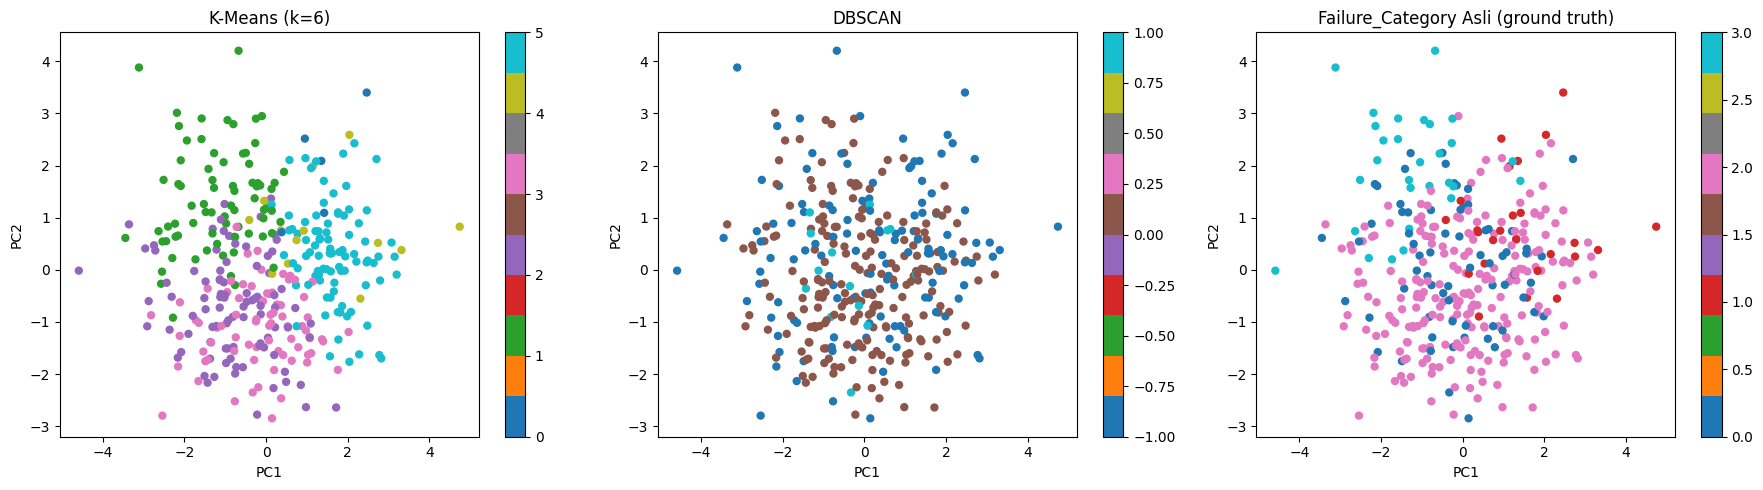

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_fail_scaled)

print(f"\nVariance explained oleh 2 komponen PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='tab10', s=25)
axes[0].set_title(f"K-Means (k={best_k})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, cmap='tab10', s=25)
axes[1].set_title("DBSCAN")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[1])

cat_codes = cat_ref_fail.astype('category').cat.codes
sc2 = axes[2].scatter(X_pca[:,0], X_pca[:,1], c=cat_codes, cmap='tab10', s=25)
axes[2].set_title("Failure_Category Asli (ground truth)")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[2])

plt.tight_layout()
plt.show()

### 8.7 Simpan hasil cluster kembali ke dataframe (buat dashboard)

In [11]:
result_fail = df.loc[fail_mask, ['Sample_ID', 'Batch_Code', 'Product_Name']].reset_index(drop=True)
result_fail['Failure_Category_Original'] = cat_ref_fail
result_fail['KMeans_Cluster'] = kmeans_labels
result_fail['DBSCAN_Cluster'] = dbscan_labels

result_fail.to_csv("bqis_clustering_result.csv", index=False)
print("\nSaved: bqis_clustering_result.csv")
print(result_fail.head(10))


Saved: bqis_clustering_result.csv
       Sample_ID  Batch_Code        Product_Name Failure_Category_Original  \
0  SPL-2026-0996  B-250102-6      Cracker Filled               Heavy_Metal   
1  SPL-2026-0294  B-250103-6    Sandwich Biscuit           Physicochemical   
2  SPL-2026-0550  B-250103-2      Cracker Filled           Microbiological   
3  SPL-2026-0175  B-250105-2      Cracker Filled           Physicochemical   
4  SPL-2026-0807  B-250105-3       Cracker Plain           Physicochemical   
5  SPL-2026-0682  B-250107-1      Butter Biscuit           Physicochemical   
6  SPL-2026-0038  B-250108-1  Cookies Choco Chip           Physicochemical   
7  SPL-2026-0652  B-250110-8      Cracker Filled               Heavy_Metal   
8  SPL-2026-0594  B-250111-1       Wafer Vanilla           Physicochemical   
9  SPL-2026-0944  B-250117-2       Cracker Plain                 Stability   

   KMeans_Cluster  DBSCAN_Cluster  
0               1              -1  
1               2               0 

In [13]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# Load hasil clustering yang udah disimpan
result = pd.read_csv("bqis_clustering_result.csv")

# Hitung ARI langsung dari kolom yang udah ada
ari_kmeans = adjusted_rand_score(
    result['Failure_Category_Original'],
    result['KMeans_Cluster']
)

ari_dbscan = adjusted_rand_score(
    result['Failure_Category_Original'],
    result['DBSCAN_Cluster']
)

print("ARI K-Means:", round(ari_kmeans, 3))
print("ARI DBSCAN :", round(ari_dbscan, 3))

# Bonus: cek persentase noise DBSCAN
n_noise = (result['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN noise: {n_noise} dari {len(result)} sampel ({n_noise/len(result)*100:.1f}%)")

ARI K-Means: 0.13
ARI DBSCAN : 0.281
DBSCAN noise: 124 dari 348 sampel (35.6%)


## Validasi Clustering: ARI & NMI

Karena K-Means/DBSCAN bersifat *unsupervised* (tidak diberi tahu kategori kegagalan asli),
kami membandingkan hasil clustering terhadap `Failure_Category` historis menggunakan dua
metrik komplementer:

- **ARI (Adjusted Rand Index)**: mengukur kesesuaian pada level PASANGAN sampel, sudah
  dikoreksi terhadap bias random assignment. Range -1 s.d. 1 (1 = sempurna, 0 = setara
  tebakan acak).
- **NMI (Normalized Mutual Information)**: mengukur seberapa banyak informasi yang
  "dibagi" antara cluster dan kategori asli. Range 0 s.d. 1, lebih toleran terhadap
  perbedaan jumlah cluster dibanding ARI.

Keduanya dipakai BERSAMAAN sebagai validasi silang -- kalau ARI dan NMI konsisten satu
sama lain, hasil clustering dianggap stabil, bukan artefak dari satu metrik saja.

**Catatan:** ARI/NMI hanya valid dihitung jika ground truth (kategori asli) tersedia.
Jika data produksi nanti tidak memiliki sub-kategori kegagalan, validasi otomatis
fallback ke Silhouette Score (lihat fungsi `suggest_eps` dan `select_features`).